# Chapter 11 (extras) — Marcus theory of electron transfer for adsorbed species

*Supplement to Chapter 11 of Michael Honeychurch, **Simulating Electrochemical
Reactions in Mathematica** (SERM). Where the main chapter uses Butler–Volmer
kinetics for a surface-confined couple, SERM's final section replaces the rate
law with the **Marcus–Hush** electron-transfer model. This notebook
re-implements the Marcus rate integral with `scipy.integrate.quad`, contrasts
the resulting rate constants and finite-difference voltammograms with
Butler–Volmer, and validates the three signature predictions of the model.*

## Why Marcus theory

Butler–Volmer (BV) kinetics writes the heterogeneous rate constants as bare
exponentials of overpotential,

$$ k_f = k_s\,e^{-\alpha f \eta}, \qquad k_b = k_s\,e^{(1-\alpha) f \eta},
   \qquad f = \frac{F}{RT}, \quad \eta = E - E^{\circ\prime}. $$

This grows without bound as $|\eta|\to\infty$ — at $\eta=-2$ V it predicts a rate
$\sim 10^{16}\,k_s$, which is unphysical. **Marcus theory** instead treats the
electron transfer between a localized redox centre and a *continuum* of electronic
states in the metal. Integrating the Marcus Gaussian activation factor against
the Fermi–Dirac occupancy of the metal states gives, for weak electronic coupling,

$$ k_{f/b}(\eta)
   = k_{\max}\,\sqrt{\frac{RT}{4\pi\lambda}}
     \int_{-\infty}^{\infty}
     \frac{\exp\!\Bigl[-\dfrac{RT}{4\lambda}
            \Bigl(\dfrac{\lambda \pm F\eta}{RT} - x\Bigr)^{2}\Bigr]}
          {1 + e^{x}}\,\mathrm{d}x, $$

where $\lambda$ is the **reorganisation energy**, $x$ a dimensionless integration
variable (electron energy measured from the Fermi level in units of $RT$), and
the $+$ / $-$ sign gives the cathodic / anodic rate. $k_{\max}$ is the maximum
rate constant (reached at high overpotential). This is SERM's eqn for the Marcus
rate; the integral has no closed form and must be evaluated numerically.

The standard rate constant $k_s$ is the rate at zero overpotential, so we fix
$k_{\max}$ by requiring $k_{f}(\eta=0)=k_s$:

$$ k_{\max} = k_s \Big/
   \left[\sqrt{\frac{RT}{4\pi\lambda}}
   \int_{-\infty}^{\infty}
   \frac{\exp\!\bigl[-\frac{RT}{4\lambda}(\frac{\lambda}{RT}-x)^2\bigr]}
        {1+e^{x}}\,\mathrm{d}x\right]. $$

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('../..'))

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

from serm.echem import F, R

T = 298.15            # K
RT = R * T            # J/mol
f_RT = F / RT         # F/RT  (1/V)


def marcus_rate_integral(eta, lam_eV, sign=+1, k_max=1.0):
    """Marcus-Hush heterogeneous rate constant for a surface redox centre.

    Evaluates, with scipy.integrate.quad,

        k = k_max * sqrt(RT/4 pi lambda) *
            Int_{-inf}^{inf} exp[-(RT/4 lambda)((lambda + sign F eta)/RT - x)^2]
                             / (1 + e^x)  dx .

    The integrand is a Gaussian in x (centred at ``c = (lambda + sign F eta)/RT``
    with std dev ``sigma = sqrt(2 lambda/RT)``) times the Fermi factor
    ``1/(1+e^x)`` (which turns over near x = 0). We give ``quad`` a finite
    window covering both features and pass ``points=[0, c]`` as break points so
    the adaptive rule resolves both peaks; the exponentials are clamped so the
    evaluation is free of overflow/underflow for any lambda. (SERM notes that
    placing finite limits on the integral and integrating numerically gives
    accurate results.)

    Parameters
    ----------
    eta : float
        Overpotential E - E0 (volts).
    lam_eV : float
        Reorganisation energy (eV). Internally lambda = lam_eV * F (J/mol),
        matching SERM's ``lambda = 0.85 * F``.
    sign : int
        +1 for the cathodic (forward/reductive) rate, -1 for the anodic.
    k_max : float
        Maximum rate constant prefactor (s^-1).

    Returns
    -------
    float
        Heterogeneous rate constant (units of ``k_max``).
    """
    lam = lam_eV * F
    a = RT / (4.0 * lam)
    centre = (lam + sign * F * eta) / RT
    sigma = np.sqrt(1.0 / (2.0 * a))

    def integrand(x):
        expo = -a * (centre - x) ** 2
        gauss = np.exp(expo) if expo > -700.0 else 0.0
        return gauss / (1.0 + np.exp(x if x < 700.0 else 700.0))

    lo = min(-50.0, centre - 10.0 * sigma)
    hi = max(50.0, centre + 10.0 * sigma)
    breaks = [p for p in (0.0, centre) if lo < p < hi]
    val, _ = quad(integrand, lo, hi, limit=400,
                  points=breaks if breaks else None)
    return k_max * np.sqrt(RT / (4.0 * np.pi * lam)) * val


def marcus_kmax(k_s, lam_eV):
    """k_max that makes the Marcus forward rate equal k_s at eta = 0."""
    y = marcus_rate_integral(0.0, lam_eV, sign=+1, k_max=1.0)
    return k_s / y


def marcus_rates(eta, lam_eV, k_s):
    """Forward (cathodic) and backward (anodic) Marcus rates, vectorized in eta."""
    k_max = marcus_kmax(k_s, lam_eV)
    eta = np.atleast_1d(np.asarray(eta, dtype=float))
    k_f = np.array([marcus_rate_integral(e, lam_eV, +1, k_max) for e in eta])
    k_b = np.array([marcus_rate_integral(e, lam_eV, -1, k_max) for e in eta])
    return k_f, k_b


## Marcus vs Butler–Volmer rate constants

We follow SERM and take $k_s = 1\ \mathrm{s^{-1}}$, $\lambda = 0.85$ eV. The
plot below shows $\ln(k_f + k_b)$ against overpotential for Marcus and for BV
($\alpha=\tfrac12$). Three features stand out:

* **Near $\eta=0$** the two models agree — the Marcus integrand is locally
  exponential, so the Marcus rate tracks BV at small overpotential.
* **At high overpotential** the Marcus rate **saturates at $k_{\max}$**: once
  $|F\eta| \gtrsim \lambda$ the activation barrier vanishes and the rate is
  limited by the density of metal states, not the driving force. BV, by
  contrast, keeps climbing exponentially.
* At $\eta = -\lambda/F$ (i.e. $F\eta = -\lambda$) the forward rate is exactly
  $k_{\max}/2$ — a clean diagnostic of the reorganisation energy.

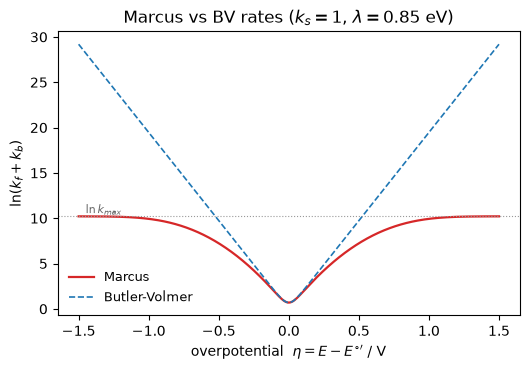

k_max = 2.709e+04 s^-1
k_f(eta = -lambda/F = -0.850 V) / k_max = 0.5000  (exact 0.5)


In [2]:
k_s = 1.0
lam_eV = 0.85
eta = np.linspace(-1.5, 1.5, 301)

k_f, k_b = marcus_rates(eta, lam_eV, k_s)
k_max = marcus_kmax(k_s, lam_eV)

# Butler-Volmer rates, alpha = 1/2.
alpha = 0.5
kf_bv = k_s * np.exp(-alpha * f_RT * eta)
kb_bv = k_s * np.exp((1.0 - alpha) * f_RT * eta)

fig, ax = plt.subplots(figsize=(5.4, 3.8))
ax.plot(eta, np.log(k_f + k_b), color="C3", lw=1.6, label="Marcus")
ax.plot(eta, np.log(kf_bv + kb_bv), "--", color="C0", lw=1.2,
        label="Butler-Volmer")
ax.axhline(np.log(k_max), color="0.6", ls=":", lw=0.8)
ax.text(-1.45, np.log(k_max) + 0.3, r"$\ln k_{max}$", fontsize=8, color="0.4")
ax.set_xlabel(r"overpotential  $\eta = E - E^{\circ\prime}$ / V")
ax.set_ylabel(r"$\ln(k_f + k_b)$")
ax.set_title(rf"Marcus vs BV rates ($k_s=1$, $\lambda={lam_eV}$ eV)")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

print(f"k_max = {k_max:.4g} s^-1")
print(f"k_f(eta = -lambda/F = {-lam_eV:.3f} V) / k_max ="
      f" {marcus_rate_integral(-lam_eV, lam_eV, +1, k_max) / k_max:.4f}"
      f"  (exact 0.5)")


## Marcus-kinetics finite-difference voltammograms

The surface-wave finite-difference stepping recursion of the main chapter
carries over unchanged once the BV rates are replaced by Marcus rates. The
sweep is a sequence of small potential steps; within each step the rates are
momentarily constant, so the oxidised mole fraction relaxes exactly toward the
local equilibrium $x_\mathrm{O}^{\,\mathrm{eq}} = k_b/(k_f+k_b)$:

$$ \Delta x_\mathrm{O}
   = \bigl(x_\mathrm{O}^{\,\mathrm{eq}} - x_\mathrm{O}\bigr)
     \bigl(1 - e^{-(k_f+k_b)\,\Delta t}\bigr),
   \qquad i \propto \frac{\Delta x_\mathrm{O}}{\Delta t}. $$

Because the Marcus integral is expensive, we evaluate $k_f(\eta),k_b(\eta)$ once
on the potential grid and reuse them for every sweep rate (exactly SERM's
strategy of tabulating the rates and recalling them). The sweep rate enters only
through the real time step $\Delta t = \Delta E/\upsilon$.

In [3]:
def surface_lsv_from_rates(E_volts, k_f, k_b, v):
    """Finite-difference surface-wave LSV from pre-tabulated rate constants.

    Parameters
    ----------
    E_volts : ndarray
        Monotone-increasing potential grid (volts), uniform spacing.
    k_f, k_b : ndarray
        Forward/backward rate constants (s^-1) on that grid.
    v : float
        Sweep rate (V/s); sets the real time step dt = dE / v.

    Returns
    -------
    psi : ndarray
        Per-step dx_O/dt divided by the dimensionless sweep scale
        (F v / RT), i.e. the dimensionless current. Positive oxidation peak.
    """
    dE = E_volts[1] - E_volts[0]
    dt = dE / v
    k_sum = k_f + k_b
    x_eq = k_b / k_sum
    x_O = x_eq[0]
    dxO = np.empty_like(E_volts)
    for j in range(E_volts.size):
        relax = (x_eq[j] - x_O) * (1.0 - np.exp(-k_sum[j] * dt))
        x_O += relax
        dxO[j] = relax
    # dimensionless current: (dx_O/dt) / (F v / RT) = (dx_O/dE) * RT/F
    return (dxO / dt) / (f_RT * v)


# Tabulate Marcus rates once on a fine potential grid (this is the slow step).
E_grid = np.linspace(-1.5, 1.5, 601)          # volts
kf_grid, kb_grid = marcus_rates(E_grid, lam_eV, k_s)
print("tabulated Marcus rates on", E_grid.size, "potential points")


tabulated Marcus rates on 601 potential points


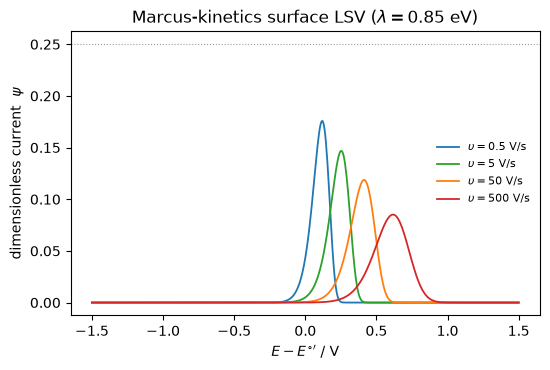

sweep rate (V/s)   peak E (V)   peak psi
       0.5        +0.120     0.1758
       5.0        +0.255     0.1468
      50.0        +0.415     0.1187
     500.0        +0.615     0.0852


In [4]:
# Voltammograms at a spread of sweep rates, reusing the tabulated rates.
sweep_rates = [0.5, 5.0, 50.0, 500.0]
colors = ["C0", "C2", "C1", "C3"]

fig, ax = plt.subplots(figsize=(5.6, 3.8))
peaks = {}
for v, c in zip(sweep_rates, colors):
    psi = surface_lsv_from_rates(E_grid, kf_grid, kb_grid, v)
    ax.plot(E_grid, psi, color=c, lw=1.3, label=fr"$\upsilon={v:g}$ V/s")
    peaks[v] = (E_grid[np.argmax(psi)], psi.max())
ax.axhline(0.25, color="0.6", ls=":", lw=0.8)
ax.set_xlabel(r"$E - E^{\circ\prime}$ / V")
ax.set_ylabel(r"dimensionless current  $\psi$")
ax.set_title(rf"Marcus-kinetics surface LSV ($\lambda={lam_eV}$ eV)")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

print("sweep rate (V/s)   peak E (V)   peak psi")
for v in sweep_rates:
    ep, pp = peaks[v]
    print(f"  {v:8.1f}        {ep:+.3f}     {pp:.4f}")


**Sweep-rate dependence of the peak shape.** This is the key qualitative
distinction SERM draws between the two kinetic models. Butler–Volmer predicts a
*constant* irreversible peak shape (peak height $\alpha\,\mathrm{e}^{-1}\approx
0.184$ for $\alpha=\tfrac12$, fixed width, independent of $k_s$ and $\upsilon$).
The Marcus model instead predicts a peak whose **height drops and whose width
grows with sweep rate** once the sweep is fast enough to push the wave into the
rate-saturated (plateau) region — the peaks broaden and flatten and develop a
diffusion-like tail. We confirm the monotone broadening below.

## Validation

Three checks, strongest first.

1. **Reduction to Butler–Volmer (Tier 2).** In the large-reorganisation-energy
   limit $\lambda\to\infty$ the Marcus Gaussian becomes flat over the region
   that matters and the Marcus rate reduces to the Butler–Volmer exponential
   with $\alpha=\tfrac12$. We assert that the Marcus/BV forward-rate ratio at a
   fixed small overpotential approaches $1$ monotonically as $\lambda$ grows.
2. **$k_{\max}$ normalisation and the $\eta=-\lambda/F$ half-height (Tier 1,
   closed-form facts).** By construction $k_f(0)=k_s$ and $k_f(-\lambda/F)=
   k_{\max}/2$; both are exact analytic statements we check to tight tolerance.
3. **Surface-coverage conservation and qualitative sweep-rate broadening
   (Tier 3).** The finite-difference march keeps $0\le x_\mathrm{O}\le 1$ at
   every step (coverage conservation), and the Marcus peak width *increases*
   with sweep rate — the qualitative signature that distinguishes Marcus from
   the sweep-rate-independent BV irreversible peak.

In [5]:
# --- 1) Marcus -> Butler-Volmer as lambda -> infinity ------------------
# At a fixed small overpotential the Marcus/BV forward-rate ratio rises
# monotonically toward 1 as the reorganisation energy grows (the Marcus
# Gaussian flattens over the relevant window and the rate becomes the bare
# BV exponential with alpha = 1/2).
eta_test = -0.1
ratios = []
lam_list = [0.85, 2.0, 5.0, 20.0, 50.0]
for lam in lam_list:
    km = marcus_kmax(k_s, lam)
    kf_m = marcus_rate_integral(eta_test, lam, +1, km)
    kf_bv = k_s * np.exp(-0.5 * f_RT * eta_test)
    ratios.append(kf_m / kf_bv)

print("lambda (eV)   k_f(Marcus)/k_f(BV) at eta = -0.1 V")
for lam, r in zip(lam_list, ratios):
    print(f"  {lam:7.2f}        {r:.5f}")

ratios = np.array(ratios)
assert np.all(np.diff(ratios) > 0), ratios          # monotone increasing
assert abs(ratios[-1] - 1.0) < 5e-3, ratios[-1]      # converges to BV
assert ratios[0] < 0.95 < ratios[-1]                 # spans below->near 1
print("\nPASS (Tier 2): Marcus reduces to Butler-Volmer as lambda -> infinity.")


lambda (eV)   k_f(Marcus)/k_f(BV) at eta = -0.1 V
     0.85        0.90396
     2.00        0.95516
     5.00        0.98128
    20.00        0.99467
    50.00        0.99833

PASS (Tier 2): Marcus reduces to Butler-Volmer as lambda -> infinity.


In [6]:
# --- 2) k_max normalisation and the eta = -lambda/F half-height -------
lam_eV = 0.85
k_max = marcus_kmax(k_s, lam_eV)

kf_0 = marcus_rate_integral(0.0, lam_eV, +1, k_max)
assert abs(kf_0 - k_s) < 1e-9, kf_0                  # k_f(0) = k_s exactly

half = marcus_rate_integral(-lam_eV, lam_eV, +1, k_max) / k_max
assert abs(half - 0.5) < 2e-3, half                  # k_f(-lambda/F) = k_max/2

# high-overpotential saturation at k_max (plateau), not BV-style divergence.
kf_plateau = marcus_rate_integral(-2.0, lam_eV, +1, k_max)
assert abs(kf_plateau / k_max - 1.0) < 1e-3, kf_plateau / k_max
assert kf_plateau < 2.0 * k_max                      # bounded (BV would be ~1e16)

print(f"k_f(0)              = {kf_0:.8f}  (k_s = 1)")
print(f"k_f(-lambda/F)/kmax = {half:.5f}  (exact 0.5)")
print(f"k_f(-2 V)/kmax      = {kf_plateau / k_max:.5f}  (plateau -> 1)")
print(f"BV k_f(-2 V)        = {k_s * np.exp(-0.5 * f_RT * -2.0):.3e}  (diverges)")
print("\nPASS (Tier 1): k_max normalisation, half-height, and plateau hold.")


k_f(0)              = 1.00000000  (k_s = 1)
k_f(-lambda/F)/kmax = 0.50000  (exact 0.5)
k_f(-2 V)/kmax      = 1.00000  (plateau -> 1)
BV k_f(-2 V)        = 8.008e+16  (diverges)

PASS (Tier 1): k_max normalisation, half-height, and plateau hold.


In [7]:
# --- 3) Coverage conservation + qualitative sweep-rate broadening -----
def marcus_lsv_with_coverage(E_volts, k_f, k_b, v):
    """Return (psi, x_O trajectory) so coverage can be checked."""
    dE = E_volts[1] - E_volts[0]
    dt = dE / v
    k_sum = k_f + k_b
    x_eq = k_b / k_sum
    x_O = x_eq[0]
    dxO = np.empty_like(E_volts)
    xtraj = np.empty_like(E_volts)
    for j in range(E_volts.size):
        relax = (x_eq[j] - x_O) * (1.0 - np.exp(-k_sum[j] * dt))
        x_O += relax
        dxO[j] = relax
        xtraj[j] = x_O
    return (dxO / dt) / (f_RT * v), xtraj


def fwhm_of(E, psi):
    """Full width at half maximum of a single positive peak (volts)."""
    jmax = np.argmax(psi)
    half = psi[jmax] / 2.0
    lft = np.interp(half, psi[:jmax + 1], E[:jmax + 1])
    rgt = np.interp(half, psi[jmax:][::-1], E[jmax:][::-1])
    return rgt - lft


widths = []
sr = [0.5, 5.0, 50.0, 500.0]
for v in sr:
    psi, xtraj = marcus_lsv_with_coverage(E_grid, kf_grid, kb_grid, v)
    # coverage conservation: x_O stays in [0,1] at every step.
    assert np.all(xtraj >= -1e-9) and np.all(xtraj <= 1.0 + 1e-9), \
        (xtraj.min(), xtraj.max())
    widths.append(fwhm_of(E_grid, psi))

widths = np.array(widths)
print("sweep rate (V/s)   Marcus peak FWHM (V)")
for v, w in zip(sr, widths):
    print(f"  {v:8.1f}          {w:.4f}")

# Qualitative Marcus signature: peak broadens monotonically with sweep rate,
# unlike the sweep-rate-INDEPENDENT Butler-Volmer irreversible peak.
assert np.all(np.diff(widths) > 0), widths
assert widths[-1] > 1.3 * widths[0], (widths[0], widths[-1])
print("\nPASS (Tier 3): coverage 0<=x_O<=1 conserved; Marcus peak broadens")
print("                monotonically with sweep rate (BV peak would not).")


sweep rate (V/s)   Marcus peak FWHM (V)
       0.5          0.1346
       5.0          0.1604
      50.0          0.1994
     500.0          0.2793

PASS (Tier 3): coverage 0<=x_O<=1 conserved; Marcus peak broadens
                monotonically with sweep rate (BV peak would not).


## Summary

* The **Marcus–Hush rate integral** was implemented with `scipy.integrate.quad`
  on a wide finite window; $k_{\max}$ is fixed by $k_f(0)=k_s$, reproducing
  SERM's normalisation.
* Marcus rates **agree with Butler–Volmer near $\eta=0$** but **saturate at
  $k_{\max}$** at high overpotential instead of diverging, with the exact
  diagnostic $k_f(-\lambda/F)=k_{\max}/2$.
* The main chapter's finite-difference stepping recursion drives **Marcus-kinetics
  voltammograms** once the rates are swapped in; tabulating the (expensive)
  rates once and reusing them across sweep rates mirrors SERM's approach.
* **Validation:** (Tier 2) Marcus → Butler–Volmer monotonically as
  $\lambda\to\infty$; (Tier 1) $k_f(0)=k_s$, $k_f(-\lambda/F)=k_{\max}/2$, and a
  bounded high-overpotential plateau; (Tier 3) surface coverage $0\le
  x_\mathrm{O}\le 1$ is conserved and the Marcus peak **broadens with sweep
  rate** — the qualitative feature that separates Marcus from the
  sweep-rate-independent Butler–Volmer irreversible peak. All checks are
  assert-backed.

<!-- nav-footer -->

---

[← Chapter 11 — Electrochemistry of Strongly Adsorbed Molecules](../11_adsorbed_species.ipynb)

[Contents (README)](../../README.md)